ARAD

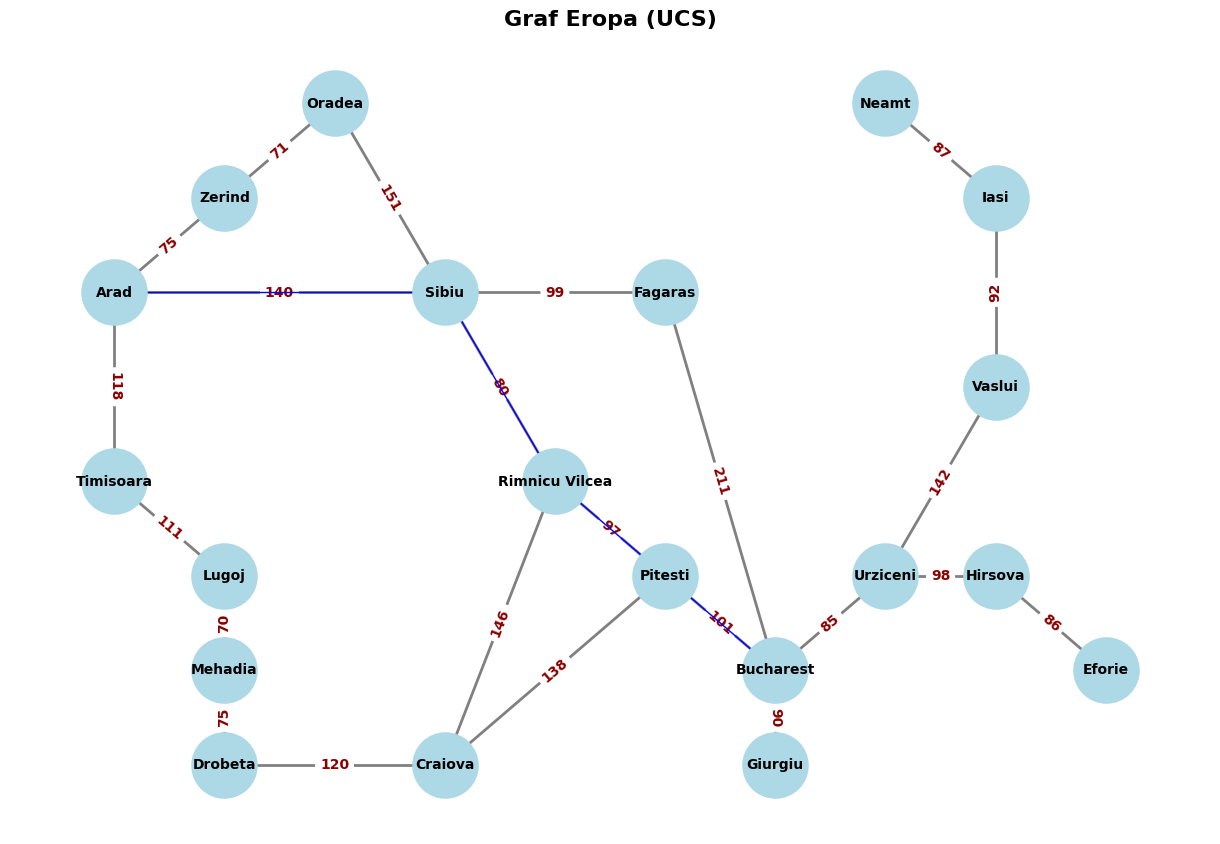

Jalur UCS (Eropa): ['Arad', 'Sibiu', 'Rimnicu Vilcea', 'Pitesti', 'Bucharest']
Total Cost: 418


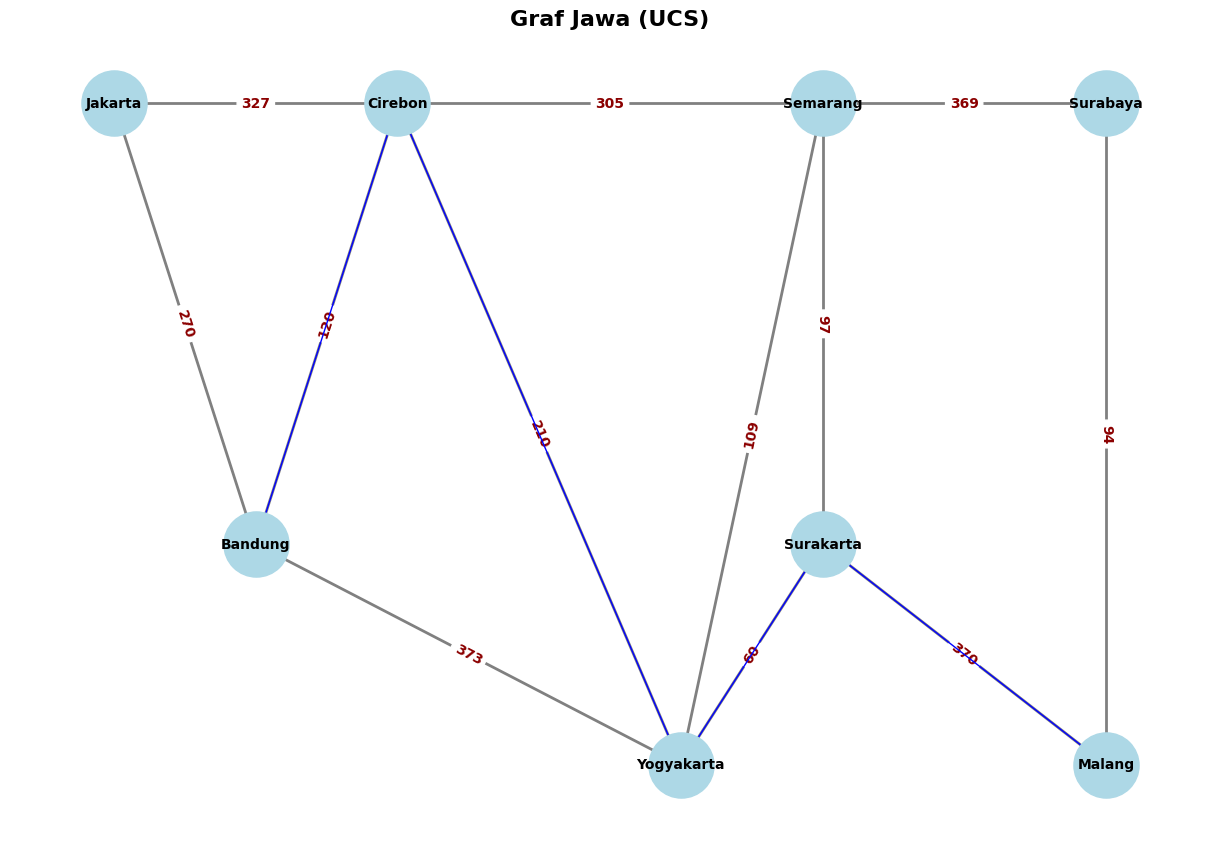


Jalur UCS (Jawa): ['Bandung', 'Cirebon', 'Yogyakarta', 'Surakarta', 'Malang']
Total Cost: 760


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

def show_graph(G, pos=None, path=None, title=''):
    plt.figure(figsize=(12, 8))
    
    #jika posisi node tidak diberikan, pakai layout otomatis
    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    #gambar graph utama 
    nx.draw(
        G, pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2200,
        font_weight='bold',
        width=2,
        edge_color='gray',
        font_size=10
    )

    #mengambil label bobot dari setiap edge
    edge_labels = nx.get_edge_attributes(G, 'weight')
    
    #menampilkan label bobot pada edge
    nx.draw_networkx_edge_labels(
        G, 
        pos,
        edge_labels=edge_labels,
        font_color='darkred',
        font_weight='bold'
    )

    #highlight jalur UCS 
    if path:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(
            G, 
            pos,
            edgelist=path_edges,
            edge_color='blue',
            width=1
        )

    #menampilkan judul graph
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

#graf Eropa

G_europe = nx.Graph()

#daftar edge + bobot jarak antar kota (Eropa)
edges_europe = [
    ('Arad', 'Zerind', 75), ('Arad', 'Timisoara', 118), ('Arad', 'Sibiu', 140),
    ('Zerind', 'Oradea', 71), ('Oradea', 'Sibiu', 151),
    ('Timisoara', 'Lugoj', 111), ('Lugoj', 'Mehadia', 70),
    ('Mehadia', 'Drobeta', 75), ('Drobeta', 'Craiova', 120),
    ('Craiova', 'Rimnicu Vilcea', 146), ('Craiova', 'Pitesti', 138),
    ('Sibiu', 'Fagaras', 99), ('Sibiu', 'Rimnicu Vilcea', 80),
    ('Fagaras', 'Bucharest', 211), ('Rimnicu Vilcea', 'Pitesti', 97),
    ('Pitesti', 'Bucharest', 101), ('Bucharest', 'Giurgiu', 90),
    ('Bucharest', 'Urziceni', 85), ('Urziceni', 'Hirsova', 98),
    ('Urziceni', 'Vaslui', 142), ('Hirsova', 'Eforie', 86),
    ('Vaslui', 'Iasi', 92), ('Iasi', 'Neamt', 87)
]

#memasukkan edge ke dalam graph
G_europe.add_weighted_edges_from(edges_europe)

#posisi manual node supaya bentuk graph rapi
pos_europe = {
    'Arad': (1, 5), 'Zerind': (2, 6), 'Oradea': (3, 7),
    'Sibiu': (4, 5), 'Timisoara': (1, 3), 'Lugoj': (2, 2),
    'Mehadia': (2, 1), 'Drobeta': (2, 0), 'Craiova': (4, 0),
    'Rimnicu Vilcea': (5, 3), 'Fagaras': (6, 5),
    'Pitesti': (6, 2), 'Bucharest': (7, 1), 'Giurgiu': (7, 0),
    'Urziceni': (8, 2), 'Hirsova': (9, 2), 'Eforie': (10, 1),
    'Vaslui': (9, 4), 'Iasi': (9, 6), 'Neamt': (8, 7)
}

#menjalankan algoritma UCS dari Arad ke Bucharest
path_europe = nx.dijkstra_path(G_europe, 'Arad', 'Bucharest', weight='weight') # cari jalur terpendek
cost_europe = nx.dijkstra_path_length(G_europe, 'Arad', 'Bucharest', weight='weight') # hitung total biaya

#menampilkan graph + jalur hasil UCS
show_graph(G_europe, pos_europe, path_europe, "Graf Eropa (UCS)")

#output hasil jalur dan total cost
print("Jalur UCS (Eropa):", path_europe)
print("Total Cost:", cost_europe)

#graf Jawa

G_java = nx.Graph()

#daftar edge dan bobot jarak antar kota di Pulau Jawa
edges_java = [
    ('Jakarta', 'Cirebon', 327), ('Jakarta', 'Bandung', 270),
    ('Cirebon', 'Bandung', 120), ('Cirebon', 'Yogyakarta', 210),
    ('Cirebon', 'Semarang', 305),
    ('Bandung', 'Yogyakarta', 373),
    ('Yogyakarta', 'Semarang', 109),
    ('Yogyakarta', 'Surakarta', 60),
    ('Semarang', 'Surakarta', 97),
    ('Semarang', 'Surabaya', 369),
    ('Surakarta', 'Malang', 370),
    ('Surabaya', 'Malang', 94)
]

#memasukkan edge ke graph
G_java.add_weighted_edges_from(edges_java)

#posisi manual node agar mudah divisualisasikan
pos_java = {
    'Jakarta': (0, 4), 'Bandung': (1, 2), 'Cirebon': (2, 4),
    'Yogyakarta': (4, 1), 'Semarang': (5, 4),
    'Surakarta': (5, 2), 'Surabaya': (7, 4), 'Malang': (7, 1)
}

#menjalankan UCS dari Bandung ke Malang
path_java = nx.dijkstra_path(G_java, 'Bandung', 'Malang', weight='weight') # cari jalur optimal
cost_java = nx.dijkstra_path_length(G_java, 'Bandung', 'Malang', weight='weight') # total biaya jalur

#menampilkan graph + hasil jalur UCS
show_graph(G_java, pos_java, path_java, "Graf Jawa (UCS)")

#output hasil jalur dan cost
print("\nJalur UCS (Jawa):", path_java)
print("Total Cost:", cost_java)
